In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.model_selection import train_test_split
#from sklearn.linear_model import
from sklearn.metrics import accuracy_score, confusion_matrix, mean_absolute_error, mean_squared_error, r2_score
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.neural_network import MLPRegressor

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout



In [2]:
# Load data
bse_30_data = pd.read_excel("sample_data/BSE_Sensex_30_Historical_Data.xlsx")
bse_30_data

,Date,Close Price,Open,High,Low,Vol.,Change %
0,28-03-2025,77414.92,77690.69,77766.70,77185.62,16.70M,-0.0025
1,27-03-2025,77606.43,77087.39,77747.46,77082.51,12.67M,0.0041
2,26-03-2025,77288.50,78021.45,78167.87,77194.22,10.48M,-0.0093
3,25-03-2025,78017.19,78296.28,78741.69,77745.63,12.67M,0.0004
4,24-03-2025,77984.38,77456.27,78107.23,77179.35,10.10M,0.0140
...,...,...,...,...,...,...,...
1236,2020-09-04 00:00:00,31159.62,30571.19,31225.20,30420.22,18.77M,0.0423
1237,2020-08-04 00:00:00,29893.96,29701.92,31227.97,29602.94,24.70M,-0.0058
1238,2020-07-04 00:00:00,30067.21,28898.36,30157.65,28602.31,21.87M,0.0897
1239,2020-03-04 00:00:00,27590.95,28623.53,28639.12,27500.79,18.91M,-0.0239


In [3]:
#Load Down Jones data
dj_ia_data = pd.read_excel("sample_data/Dow_Jones_Industrial_Average_Historical_Data.xlsx")
dj_ia_data

,Date,Close Price,Open,High,Low,Vol.,Change %
0,31-03-2025,42001.76,41382.52,42147.38,41148.13,732.22M,0.0100
1,28-03-2025,41583.90,42245.82,42258.15,41530.00,532.36M,-0.0169
2,27-03-2025,42299.70,42432.96,42523.84,42142.19,492.22M,-0.0037
3,26-03-2025,42454.79,42655.85,42821.83,42326.67,592.65M,-0.0031
4,25-03-2025,42587.50,42635.54,42696.61,42441.83,452.20M,0.0001
...,...,...,...,...,...,...,...
1252,2020-07-04 00:00:00,22653.86,23537.44,23617.24,22634.45,595.87M,-0.0012
1253,2020-06-04 00:00:00,22679.99,21693.63,22783.45,21693.63,614.20M,0.0773
1254,2020-03-04 00:00:00,21052.53,21285.93,21447.81,20863.09,451.62M,-0.0169
1255,2020-02-04 00:00:00,21413.44,20819.46,21477.77,20735.02,534.67M,0.0224


In [4]:
#check data types
bse_30_data.info()
bse_30_data.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1241 entries, 0 to 1240
Data columns (total 7 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Date         1241 non-null   object 
 1   Close Price  1241 non-null   float64
 2   Open         1241 non-null   float64
 3   High         1241 non-null   float64
 4   Low          1241 non-null   float64
 5   Vol.         1241 non-null   object 
 6   Change %     1241 non-null   float64
dtypes: float64(5), object(2)
memory usage: 68.0+ KB


,0
Date,0
Close Price,0
Open,0
High,0
Low,0
Vol.,0
Change %,0


In [5]:
dj_ia_data.info()
dj_ia_data.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1257 entries, 0 to 1256
Data columns (total 7 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Date         1257 non-null   object 
 1   Close Price  1257 non-null   float64
 2   Open         1257 non-null   float64
 3   High         1257 non-null   float64
 4   Low          1257 non-null   float64
 5   Vol.         1256 non-null   object 
 6   Change %     1257 non-null   float64
dtypes: float64(5), object(2)
memory usage: 68.9+ KB


,0
Date,0
Close Price,0
Open,0
High,0
Low,0
Vol.,1
Change %,0


In [6]:
# First make the date field proper as they are not stored in same formate.
bse_30_data['Date'] = pd.to_datetime(bse_30_data['Date'])
dj_ia_data['Date'] = pd.to_datetime(dj_ia_data['Date'])

<ipython-input-6-386ae1118cbf>:2: UserWarning: Parsing dates in %d-%m-%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  bse_30_data['Date'] = pd.to_datetime(bse_30_data['Date'])
<ipython-input-6-386ae1118cbf>:3: UserWarning: Parsing dates in %d-%m-%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  dj_ia_data['Date'] = pd.to_datetime(dj_ia_data['Date'])


In [7]:
bse_30_data

,Date,Close Price,Open,High,Low,Vol.,Change %
0,2025-03-28,77414.92,77690.69,77766.70,77185.62,16.70M,-0.0025
1,2025-03-27,77606.43,77087.39,77747.46,77082.51,12.67M,0.0041
2,2025-03-26,77288.50,78021.45,78167.87,77194.22,10.48M,-0.0093
3,2025-03-25,78017.19,78296.28,78741.69,77745.63,12.67M,0.0004
4,2025-03-24,77984.38,77456.27,78107.23,77179.35,10.10M,0.0140
...,...,...,...,...,...,...,...
1236,2020-09-04,31159.62,30571.19,31225.20,30420.22,18.77M,0.0423
1237,2020-08-04,29893.96,29701.92,31227.97,29602.94,24.70M,-0.0058
1238,2020-07-04,30067.21,28898.36,30157.65,28602.31,21.87M,0.0897
1239,2020-03-04,27590.95,28623.53,28639.12,27500.79,18.91M,-0.0239


In [8]:
dj_ia_data

,Date,Close Price,Open,High,Low,Vol.,Change %
0,2025-03-31,42001.76,41382.52,42147.38,41148.13,732.22M,0.0100
1,2025-03-28,41583.90,42245.82,42258.15,41530.00,532.36M,-0.0169
2,2025-03-27,42299.70,42432.96,42523.84,42142.19,492.22M,-0.0037
3,2025-03-26,42454.79,42655.85,42821.83,42326.67,592.65M,-0.0031
4,2025-03-25,42587.50,42635.54,42696.61,42441.83,452.20M,0.0001
...,...,...,...,...,...,...,...
1252,2020-07-04,22653.86,23537.44,23617.24,22634.45,595.87M,-0.0012
1253,2020-06-04,22679.99,21693.63,22783.45,21693.63,614.20M,0.0773
1254,2020-03-04,21052.53,21285.93,21447.81,20863.09,451.62M,-0.0169
1255,2020-02-04,21413.44,20819.46,21477.77,20735.02,534.67M,0.0224


In [9]:
#As per the data there are not equal rows in both the dataset.
#removing the non existing dates from Dow jones data.
dj_ia_data = dj_ia_data[dj_ia_data['Date'].isin(bse_30_data['Date'])]
dj_ia_data

,Date,Close Price,Open,High,Low,Vol.,Change %
1,2025-03-28,41583.90,42245.82,42258.15,41530.00,532.36M,-0.0169
2,2025-03-27,42299.70,42432.96,42523.84,42142.19,492.22M,-0.0037
3,2025-03-26,42454.79,42655.85,42821.83,42326.67,592.65M,-0.0031
4,2025-03-25,42587.50,42635.54,42696.61,42441.83,452.20M,0.0001
5,2025-03-24,42583.32,42180.14,42638.85,42180.14,548.85M,0.0142
...,...,...,...,...,...,...,...
1250,2020-09-04,23719.37,23690.66,24008.99,23504.09,568.72M,0.0122
1251,2020-08-04,23433.57,22893.47,23513.40,22682.99,476.09M,0.0344
1252,2020-07-04,22653.86,23537.44,23617.24,22634.45,595.87M,-0.0012
1254,2020-03-04,21052.53,21285.93,21447.81,20863.09,451.62M,-0.0169


In [10]:
#Analyze the correlation between DJIA and BSE Sensex prices.

dj_ia_data.dropna(subset=['Date'], inplace=True)
bse_30_data.dropna(subset=['Date'], inplace=True)
dj_ia_data
#bse_30_data


<ipython-input-10-53ab421e06fa>:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dj_ia_data.dropna(subset=['Date'], inplace=True)


,Date,Close Price,Open,High,Low,Vol.,Change %
1,2025-03-28,41583.90,42245.82,42258.15,41530.00,532.36M,-0.0169
2,2025-03-27,42299.70,42432.96,42523.84,42142.19,492.22M,-0.0037
3,2025-03-26,42454.79,42655.85,42821.83,42326.67,592.65M,-0.0031
4,2025-03-25,42587.50,42635.54,42696.61,42441.83,452.20M,0.0001
5,2025-03-24,42583.32,42180.14,42638.85,42180.14,548.85M,0.0142
...,...,...,...,...,...,...,...
1250,2020-09-04,23719.37,23690.66,24008.99,23504.09,568.72M,0.0122
1251,2020-08-04,23433.57,22893.47,23513.40,22682.99,476.09M,0.0344
1252,2020-07-04,22653.86,23537.44,23617.24,22634.45,595.87M,-0.0012
1254,2020-03-04,21052.53,21285.93,21447.81,20863.09,451.62M,-0.0169


In [11]:
#drop duplicate dates
bse_30_data.drop_duplicates(subset=['Date'], inplace=True)
#bse_30_data
dj_ia_data.drop_duplicates(subset=['Date'], inplace=True)
dj_ia_data

<ipython-input-11-301014dc2c2d>:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dj_ia_data.drop_duplicates(subset=['Date'], inplace=True)


,Date,Close Price,Open,High,Low,Vol.,Change %
1,2025-03-28,41583.90,42245.82,42258.15,41530.00,532.36M,-0.0169
2,2025-03-27,42299.70,42432.96,42523.84,42142.19,492.22M,-0.0037
3,2025-03-26,42454.79,42655.85,42821.83,42326.67,592.65M,-0.0031
4,2025-03-25,42587.50,42635.54,42696.61,42441.83,452.20M,0.0001
5,2025-03-24,42583.32,42180.14,42638.85,42180.14,548.85M,0.0142
...,...,...,...,...,...,...,...
1250,2020-09-04,23719.37,23690.66,24008.99,23504.09,568.72M,0.0122
1251,2020-08-04,23433.57,22893.47,23513.40,22682.99,476.09M,0.0344
1252,2020-07-04,22653.86,23537.44,23617.24,22634.45,595.87M,-0.0012
1254,2020-03-04,21052.53,21285.93,21447.81,20863.09,451.62M,-0.0169


In [12]:
dj_ia_data

,Date,Close Price,Open,High,Low,Vol.,Change %
1,2025-03-28,41583.90,42245.82,42258.15,41530.00,532.36M,-0.0169
2,2025-03-27,42299.70,42432.96,42523.84,42142.19,492.22M,-0.0037
3,2025-03-26,42454.79,42655.85,42821.83,42326.67,592.65M,-0.0031
4,2025-03-25,42587.50,42635.54,42696.61,42441.83,452.20M,0.0001
5,2025-03-24,42583.32,42180.14,42638.85,42180.14,548.85M,0.0142
...,...,...,...,...,...,...,...
1250,2020-09-04,23719.37,23690.66,24008.99,23504.09,568.72M,0.0122
1251,2020-08-04,23433.57,22893.47,23513.40,22682.99,476.09M,0.0344
1252,2020-07-04,22653.86,23537.44,23617.24,22634.45,595.87M,-0.0012
1254,2020-03-04,21052.53,21285.93,21447.81,20863.09,451.62M,-0.0169


In [13]:
# correlation between closing dj_ia_data and bse_30_data
correlation = dj_ia_data['Close Price'].corr(bse_30_data['Close Price'])
print("Correlation between DJIA and BSE Sensex prices:", correlation)



Correlation between DJIA and BSE Sensex prices: 0.9173448254248542


In [14]:
#merging down jones date, closing price and bse data date and closing price
final_df_ia = pd.merge(dj_ia_data, bse_30_data, on='Date', how='inner', suffixes=('_DJIA', '_BSE'))
final_df_ia


,Date,Close Price_DJIA,Open_DJIA,High_DJIA,Low_DJIA,Vol._DJIA,Change %_DJIA,Close Price_BSE,Open_BSE,High_BSE,Low_BSE,Vol._BSE,Change %_BSE
0,2025-03-28,41583.90,42245.82,42258.15,41530.00,532.36M,-0.0169,77414.92,77690.69,77766.70,77185.62,16.70M,-0.0025
1,2025-03-27,42299.70,42432.96,42523.84,42142.19,492.22M,-0.0037,77606.43,77087.39,77747.46,77082.51,12.67M,0.0041
2,2025-03-26,42454.79,42655.85,42821.83,42326.67,592.65M,-0.0031,77288.50,78021.45,78167.87,77194.22,10.48M,-0.0093
3,2025-03-25,42587.50,42635.54,42696.61,42441.83,452.20M,0.0001,78017.19,78296.28,78741.69,77745.63,12.67M,0.0004
4,2025-03-24,42583.32,42180.14,42638.85,42180.14,548.85M,0.0142,77984.38,77456.27,78107.23,77179.35,10.10M,0.0140
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1191,2020-09-04,23719.37,23690.66,24008.99,23504.09,568.72M,0.0122,31159.62,30571.19,31225.20,30420.22,18.77M,0.0423
1192,2020-08-04,23433.57,22893.47,23513.40,22682.99,476.09M,0.0344,29893.96,29701.92,31227.97,29602.94,24.70M,-0.0058
1193,2020-07-04,22653.86,23537.44,23617.24,22634.45,595.87M,-0.0012,30067.21,28898.36,30157.65,28602.31,21.87M,0.0897
1194,2020-03-04,21052.53,21285.93,21447.81,20863.09,451.62M,-0.0169,27590.95,28623.53,28639.12,27500.79,18.91M,-0.0239


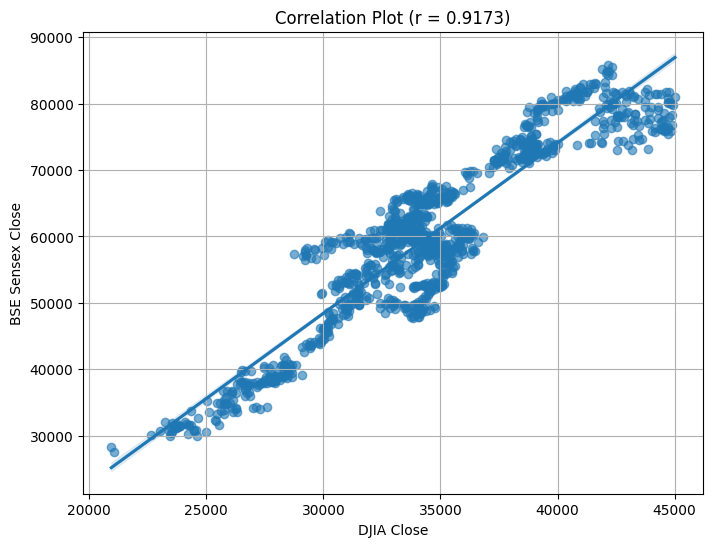

In [15]:
plt.figure(figsize=(8,6))
sns.regplot(x='Close Price_DJIA', y='Close Price_BSE', data=final_df_ia, scatter_kws={'alpha':0.6})
plt.title(f"Correlation Plot (r = {correlation:.4f})")
plt.xlabel("DJIA Close")
plt.ylabel("BSE Sensex Close")
plt.grid(True)
plt.show()

In [16]:
from typing_extensions import final
# Create lag features for DJIA from the previous 10 trading days
for lag in range(1, 11):
    final_df_ia[f'DJIA_Lag_{lag}'] = final_df_ia['Close Price_DJIA'].shift(lag)

# Drop rows with missing values caused by shifting
final_df_ia.dropna(inplace=True)

final_df_ia


,Date,Close Price_DJIA,Open_DJIA,High_DJIA,Low_DJIA,Vol._DJIA,Change %_DJIA,Close Price_BSE,Open_BSE,High_BSE,...,DJIA_Lag_1,DJIA_Lag_2,DJIA_Lag_3,DJIA_Lag_4,DJIA_Lag_5,DJIA_Lag_6,DJIA_Lag_7,DJIA_Lag_8,DJIA_Lag_9,DJIA_Lag_10
10,2025-03-13,40813.57,41280.05,41360.12,40661.77,646.78M,-0.0130,73828.91,74392.54,74401.11,...,41841.63,41581.31,41964.63,41953.32,41985.35,42583.32,42587.50,42454.79,42299.70,41583.90
11,2025-12-03,41350.93,41577.50,41721.36,41010.24,712.37M,-0.0020,74029.76,74270.81,74392.15,...,40813.57,41841.63,41581.31,41964.63,41953.32,41985.35,42583.32,42587.50,42454.79,42299.70
12,2025-11-03,41433.48,41837.95,41868.27,41175.37,828.16M,-0.0114,74102.32,73743.88,74195.17,...,41350.93,40813.57,41841.63,41581.31,41964.63,41953.32,41985.35,42583.32,42587.50,42454.79
13,2025-10-03,41911.71,42507.65,42541.36,41612.92,840.18M,-0.0208,74115.17,74474.98,74741.25,...,41433.48,41350.93,40813.57,41841.63,41581.31,41964.63,41953.32,41985.35,42583.32,42587.50
14,2025-07-03,42801.72,42503.07,42898.68,42175.62,763.44M,0.0052,74332.58,74347.14,74586.43,...,41911.71,41433.48,41350.93,40813.57,41841.63,41581.31,41964.63,41953.32,41985.35,42583.32
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1191,2020-09-04,23719.37,23690.66,24008.99,23504.09,568.72M,0.0122,31159.62,30571.19,31225.20,...,23390.77,23504.35,23537.68,24242.49,23650.44,23018.88,23475.82,23515.26,23775.27,24133.78
1192,2020-08-04,23433.57,22893.47,23513.40,22682.99,476.09M,0.0344,29893.96,29701.92,31227.97,...,23719.37,23390.77,23504.35,23537.68,24242.49,23650.44,23018.88,23475.82,23515.26,23775.27
1193,2020-07-04,22653.86,23537.44,23617.24,22634.45,595.87M,-0.0012,30067.21,28898.36,30157.65,...,23433.57,23719.37,23390.77,23504.35,23537.68,24242.49,23650.44,23018.88,23475.82,23515.26
1194,2020-03-04,21052.53,21285.93,21447.81,20863.09,451.62M,-0.0169,27590.95,28623.53,28639.12,...,22653.86,23433.57,23719.37,23390.77,23504.35,23537.68,24242.49,23650.44,23018.88,23475.82


In [17]:
#Split features and target
feature_cols = [f'DJIA_Lag_{i}' for i in range(1, 11)]
X = final_df_ia[feature_cols]
y = final_df_ia['Close Price_BSE']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)



In [18]:
def evaluate_model(name, model, X_test, y_test):
    y_pred = model.predict(X_test)
    mae = mean_absolute_error(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)
    print(f"{name} Results:")
    print(f"MAE: {mae:.2f}")
    print(f"MSE: {mse:.2f}")
    print(f"R2 Score: {r2:.2f}\\n")
    return y_pred

In [19]:
# Linear Regression
lr = LinearRegression()
lr.fit(X_train_scaled, y_train)
lr_pred = evaluate_model("Linear Regression", lr, X_test_scaled, y_test)
print("\n____________________________________________________________________________________________________\n")
# Random Forest
rf = RandomForestRegressor(random_state=42)
rf.fit(X_train_scaled, y_train)
rf_pred = evaluate_model("Random Forest", rf, X_test_scaled, y_test)
print("\n____________________________________________________________________________________________________\n")
# XGBoost
xgb = XGBRegressor(random_state=42)
xgb.fit(X_train_scaled, y_train)
xgb_pred = evaluate_model("XGBoost", xgb, X_test_scaled, y_test)

Linear Regression Results:
MAE: 4176.16
MSE: 24118660.74
R2 Score: 0.85\n

____________________________________________________________________________________________________

Random Forest Results:
MAE: 3002.84
MSE: 16526343.06
R2 Score: 0.90\n

____________________________________________________________________________________________________

XGBoost Results:
MAE: 3085.07
MSE: 17402033.71
R2 Score: 0.89\n


In [20]:
#7. Deep Learning Model
model = Sequential([
    Dense(128, activation='relu', input_shape=(X_train.shape[1],)),
    Dropout(0.2),
    Dense(64, activation='relu'),
    Dropout(0.1),
    Dense(1)
])

# Compile the model
model.compile(optimizer='adam', loss='mse', metrics=['mae'])

# Fit the model
history = model.fit(
    X_train_scaled, y_train,
    validation_split=0.2,
    epochs=100,
    batch_size=16,
    verbose=1
)

# Performance Evaluate
y_pred = model.predict(X_test_scaled).flatten()

mse = mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("📊 Deep Learning (Keras Sequential) Performance:")
print(f"MAE: {mae:.2f}")
print(f"MSE: {mse:.2f}")
print(f"R² Score: {r2:.4f}")



/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/100
48/48 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - loss: 3739529216.0000 - mae: 59710.5352 - val_loss: 3607883008.0000 - val_mae: 58614.7383
Epoch 2/100
48/48 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 3776093440.0000 - mae: 60006.5820 - val_loss: 3598439680.0000 - val_mae: 58533.7109
Epoch 3/100
48/48 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 3788541184.0000 - mae: 60092.5000 - val_loss: 3570545920.0000 - val_mae: 58292.1641
Epoch 4/100
48/48 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 3693995776.0000 - mae: 59336.7305 - val_loss: 3510995200.0000 - val_mae: 57770.3984
Epoch 5/100
48/48 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 3702868736.0000 - mae: 59480.5742 - val_loss: 3410138880.0000 - val_mae: 56871.6719
Epoch 6/100
48/48 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 3580773376.0000 - mae: 58392.9375 - val_loss: 3261679360.0000 - val_mae: 55505.2734
Epoch 7/100
48/48 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 3392269312.0000 - mae: 56845.5273 - val_loss: 3064298496.0000 - val_mae: 53596.92

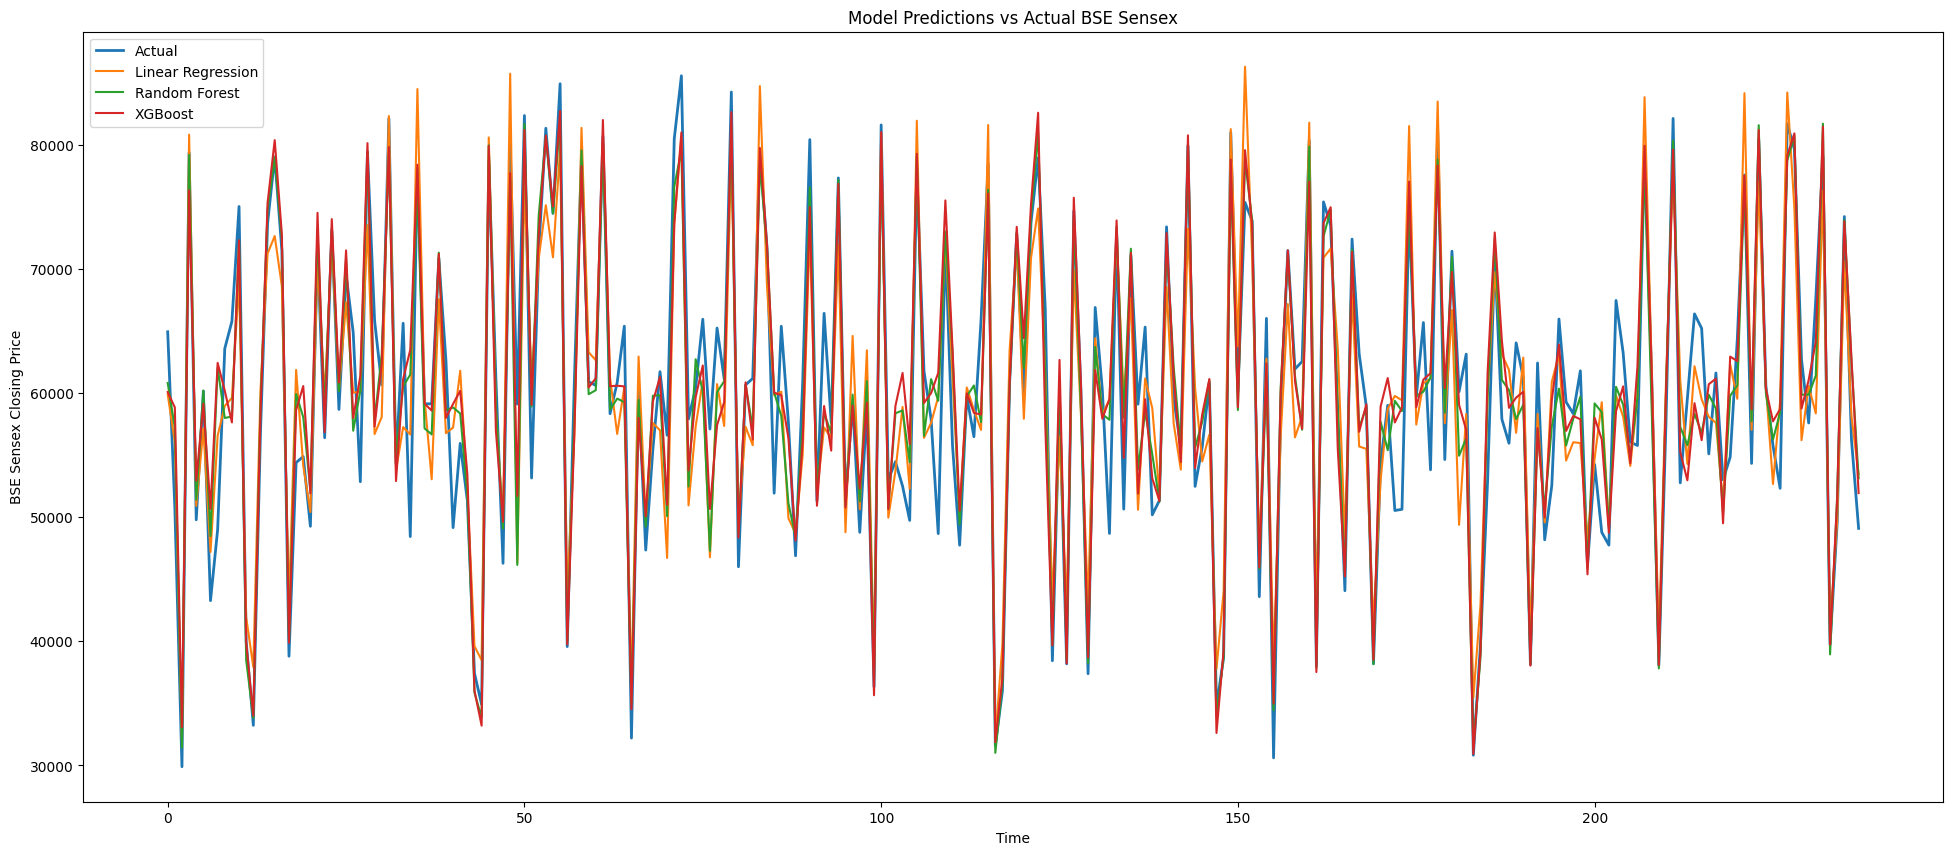

In [21]:
# 8. Compare Predictions
plt.figure(figsize=(24,10))
plt.plot(y_test.values, label='Actual', linewidth=2)
plt.plot(lr_pred, label='Linear Regression')
plt.plot(rf_pred, label='Random Forest')
plt.plot(xgb_pred, label='XGBoost')
plt.legend()
plt.title("Model Predictions vs Actual BSE Sensex")
plt.xlabel("Time")
plt.ylabel("BSE Sensex Closing Price")
plt.show()


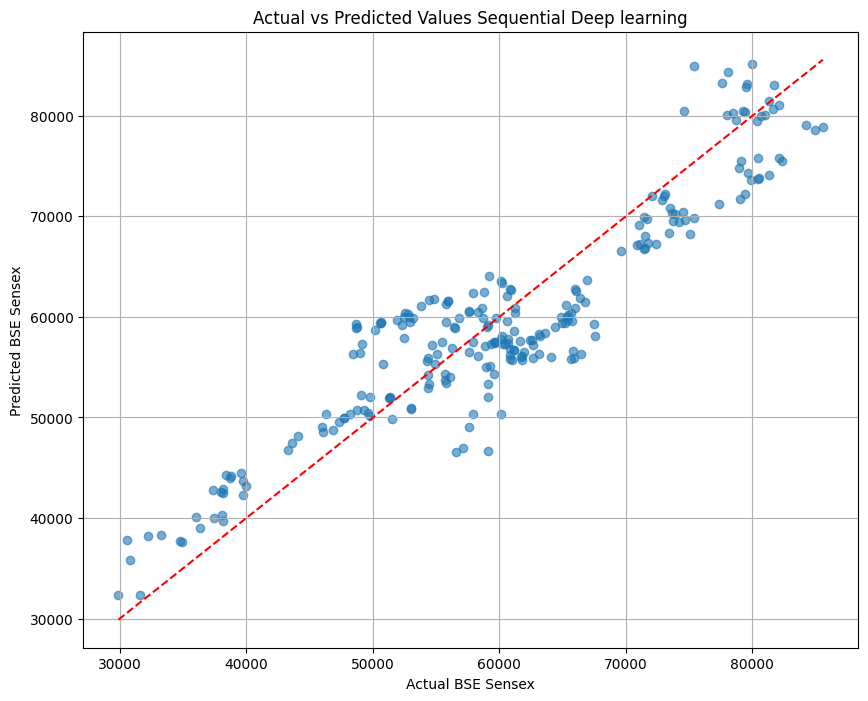

In [22]:
#Scatter Plot
plt.figure(figsize=(10, 8))
plt.scatter(y_test, y_pred, alpha=0.6)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')  # 45-degree line
plt.xlabel("Actual BSE Sensex")
plt.ylabel("Predicted BSE Sensex")
plt.title("Actual vs Predicted Values Sequential Deep learning")
plt.grid(True)
plt.show()


In [23]:
# Sequential Model


**Research Questions:**

**1**) Is there a statistically significant relationship between DJIA prices and BSE Sensex prices?

As per the cor-relation there is strong relation between DJIA prices and BSE Sensex prices.

0.90


------------------------------------------------------------------------------


**2**) Can DJIA prices from the previous 10 days reliably predict BSE Sensex pricess
Based on Different Models like Linera Regression, Random Froest and XGBoost R score is greater predication relations from DJIA 10 day to BASE 30 Sensex.




---




**3**) Which machine learning model provides the best predictive performance for this task?

Linear Regression Results:
MAE: 4176.16
MSE: 24118660.74
R2 Score: 0.85


Random Forest Results:
MAE: 3002.84
MSE: 16526343.06
R2 Score: 0.90


XGBoost Results:
MAE: 3085.07
MSE: 17402033.71
R2 Score: 0.89

Random Forest


---


**4**) How do external factors (e.g., market volatility, holidays) impact model accuracy?

Holiday and market volatility may effect the data , as there was no such data in the dataset , cannot say perfectly that how that might be affecting the performance of the model and how much.
